# 🛰️ AEGIS-LINK — Analisi Run

Notebook locale (ignorato da git) per visualizzare i risultati di una simulazione.

**Prerequisito:** aver eseguito `./run_demo.sh` almeno una volta (genera `run.csv`).

---

## Indice
1. Setup & lettura dati
2. Sanity check del run
3. Traiettoria 3D (truth vs estimate)
4. Errore di posizione nel tempo
5. Distanza di Mahalanobis $d^2$ + soglie $\chi^2$
6. Distribuzione di $d^2$ e test di consistenza
7. Statistica dei residui
8. Diagnostica timing (rate effettivo)
9. (Opz.) test di manovra

## 1. Setup & lettura dati

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "lines.linewidth": 1.2,
})

# -- Parametri di analisi -----------------------------------------------------
CSV          = "run.csv"
WARMUP_S     = 10.0   # secondi iniziali da scartare nelle statistiche aggregate.
                      # L'EKF parte da P0 = 1e3·I (molto incerto). Convergenza tipica:
                      #   t in [0, 5)s   -> RMSE ~ 100 m  (sta agganciando)
                      #   t in [5, 10)s  -> RMSE ~ 300 m  (overshoot: impara a_z = -g)
                      #   t >= 10 s      -> RMSE ~ 0.1 m  (sub-decimetrico, in regime)

# -- Caricamento --------------------------------------------------------------
df = pd.read_csv(CSV)
df["t_s"]      = (df.ts_ns - df.ts_ns.iloc[0]) * 1e-9
df["err_x"]    = df.px - df.ex
df["err_y"]    = df.py - df.ey
df["err_z"]    = df.pz - df.ez
df["err_norm"] = np.linalg.norm(df[["err_x","err_y","err_z"]].values, axis=1)

# Sotto-dataframe "in regime" (dopo il warm-up del filtro)
ss = df[df.t_s >= WARMUP_S].reset_index(drop=True)

print(f"Samples totali     : {len(df):,}")
print(f"Durata             : {df.t_s.iloc[-1]:.2f} s")
print(f"Rate               : {len(df) / df.t_s.iloc[-1]:.2f} Hz")
print(f"Warm-up scartato   : primi {WARMUP_S:.1f} s ({len(df)-len(ss)} sample)")
print(f"Sample 'in regime' : {len(ss):,}")
df.head()


Samples totali     : 508
Durata             : 5.07 s
Rate               : 100.20 Hz
Warm-up scartato   : primi 10.0 s (508 sample)
Sample 'in regime' : 0


,ts_ns,packet_id,d2,maneuver,px,py,pz,ex,ey,ez,t_s,err_x,err_y,err_z,err_norm
0,1778847306654359479,106,40941.7760,0,96.722,5.765,472.826,37.484,0.128,197.186,0.000000,59.238,5.637,275.640,281.989940
1,1778847306664688470,107,38642.1921,0,97.235,5.824,475.138,38.004,0.130,199.788,0.010329,59.231,5.694,275.350,281.706151
2,1778847306674074782,108,36779.6882,1,97.749,5.883,477.450,38.470,0.131,202.119,0.019715,59.279,5.752,275.331,281.698855
3,1778847306684373303,109,34762.7263,1,98.262,5.942,479.760,38.990,0.132,204.721,0.030014,59.272,5.810,275.039,281.413180
4,1778847306694785277,110,32893.4400,1,98.776,6.002,482.070,39.507,0.134,207.307,0.040426,59.269,5.868,274.763,281.144009


## 2. Sanity check

> ⚠️ **Importante:** l'EKF parte con $P_0 = 10^3 \cdot I$ (covarianza iniziale enorme,
> totale ignoranza dello stato). Per i primi secondi converge da posizione/velocità
> sbagliate verso lo stato vero, producendo $d^2$ enormi. Questo è **fisiologico**
> e non un bug. Tutti i test statistici aggregati vanno fatti **dopo il warm-up**.

Cose che devono essere vere:
- nessun `NaN` nelle colonne;
- `packet_id` strettamente crescente (no riordini ZMQ);
- `median(d²) ≈ 5.35` **post warm-up** ⇒ filtro consistente
  (la mediana è robusta agli outlier; la media no).


In [2]:
ok_nan   = not df.isna().any().any()
ok_order = (df.packet_id.diff().dropna() > 0).all()

# χ² teoriche per 6 dof
chi2_mean    = 6.0
chi2_median  = stats.chi2.ppf(0.5, df=6)   # ~ 5.35
chi2_p99     = stats.chi2.ppf(0.99, df=6)  # ~ 16.81

print("=== INTERA RUN (incluso warm-up) ===")
print(f"NaN-free                 : {ok_nan}")
print(f"packet_id monotono       : {ok_order}")
print(f"mean(d^2)                : {df.d2.mean():12.2f}   << dominato dal transitorio")
print(f"median(d^2)              : {df.d2.median():12.2f}")
print(f"max(d^2)                 : {df.d2.max():12.2f}")
print()
print(f"=== POST WARM-UP (t > {WARMUP_S}s, n={len(ss)}) ===")
print(f"mean(d^2)                : {ss.d2.mean():12.2f}   (atteso ~ {chi2_mean:.2f})")
print(f"median(d^2)              : {ss.d2.median():12.2f}   (atteso ~ {chi2_median:.2f})")
print(f"frazione d^2 > chi2_99%  : {(ss.d2 > chi2_p99).mean()*100:5.2f} %   (atteso ~ 1 %)")
print(f"frame con maneuver=1     : {ss.maneuver.sum()} / {len(ss)}   "
      f"({ss.maneuver.mean()*100:.1f} %)")

# Verdetto sintetico
status = "✅ OK"
notes = []
if ss.d2.median() > 2 * chi2_median:
    status = "⚠️  Q troppo piccolo (filtro troppo rigido)"
elif ss.d2.median() < 0.3 * chi2_median:
    status = "⚠️  Q troppo grande (filtro troppo molle)"
print(f"\nVerdetto consistency : {status}")


=== INTERA RUN (incluso warm-up) ===
NaN-free                 : True
packet_id monotono       : True
mean(d^2)                :      1838.40   << dominato dal transitorio
median(d^2)              :        61.37
max(d^2)                 :     40941.78

=== POST WARM-UP (t > 10.0s, n=0) ===
mean(d^2)                :          nan   (atteso ~ 6.00)
median(d^2)              :          nan   (atteso ~ 5.35)
frazione d^2 > chi2_99%  :   nan %   (atteso ~ 1 %)
frame con maneuver=1     : 0 / 0   (nan %)

Verdetto consistency : ✅ OK


## 3. Traiettoria 3D — truth vs estimate

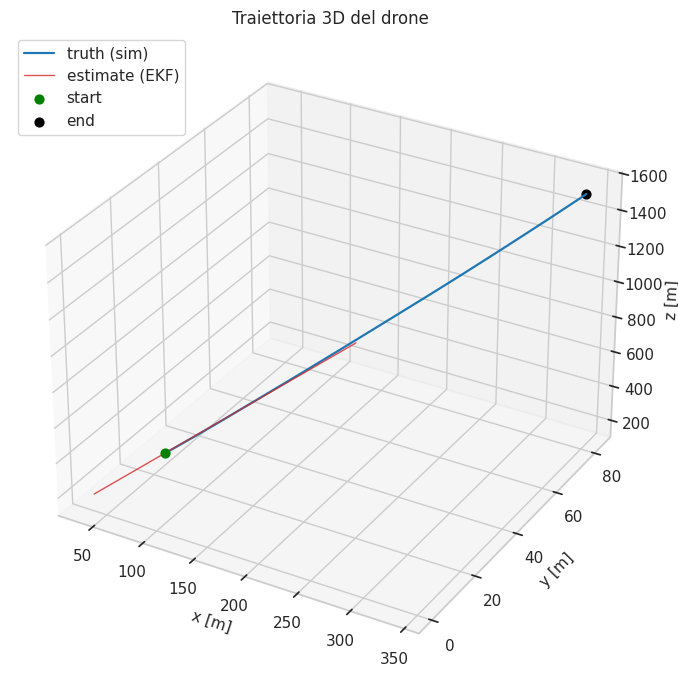

In [3]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot(df.px, df.py, df.pz, label="truth (sim)", color="#1f77b4", lw=1.6)
ax.plot(df.ex, df.ey, df.ez, label="estimate (EKF)", color="#d62728", lw=1.0, alpha=0.8)
ax.scatter(df.px.iloc[0], df.py.iloc[0], df.pz.iloc[0],  c="green", s=40, label="start")
ax.scatter(df.px.iloc[-1], df.py.iloc[-1], df.pz.iloc[-1], c="black", s=40, label="end")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_zlabel("z [m]")
ax.set_title("Traiettoria 3D del drone")
ax.legend(loc="upper left"); plt.tight_layout(); plt.show()

## 4. Errore di posizione nel tempo

Per ogni componente: $\Delta = \text{truth} - \hat{x}$. La banda grigia è $\pm 3\sigma$ del rumore di misura nominale.

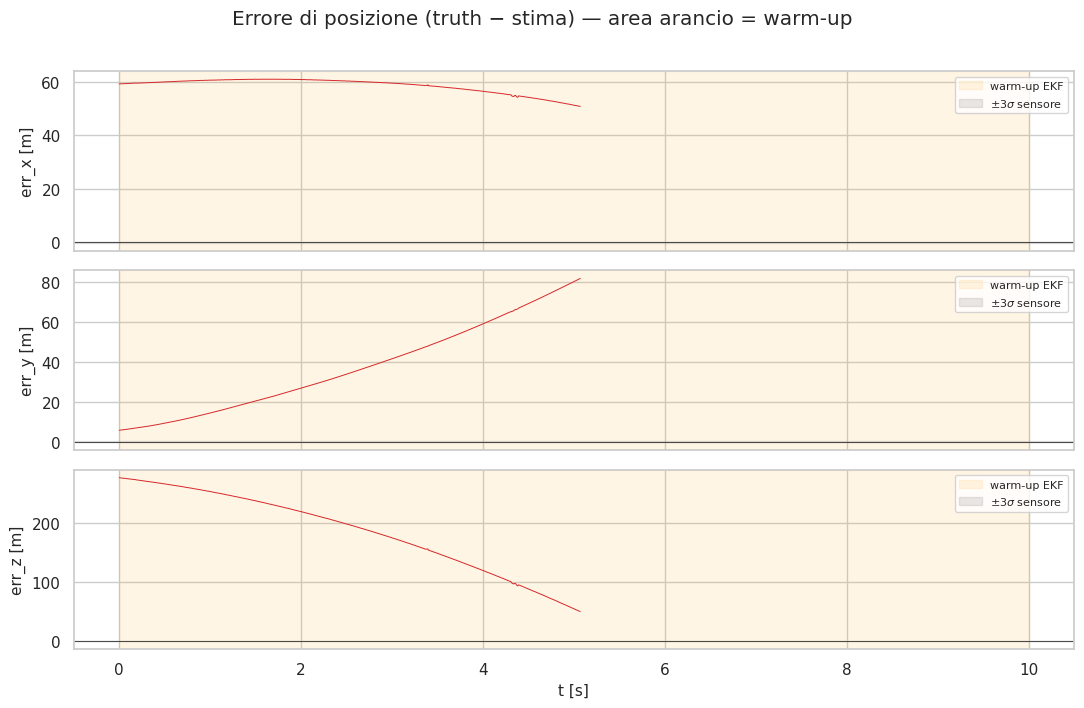

RMSE INTERO RUN (incluso warm-up):
  x:  58613.2 mm
  y:  43251.5 mm
  z: 196149.0 mm
  3D: 209238.2 mm

RMSE POST WARM-UP (t > 10.0s):
  x:      nan mm
  y:      nan mm
  z:      nan mm
  3D:      nan mm   <-- questo è il numero da citare


In [4]:
R_POS_STD = 0.05  # m, deve combaciare con tracking_system/main.cpp

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
for ax, comp in zip(axes, ["x", "y", "z"]):
    e = df[f"err_{comp}"]
    ax.plot(df.t_s, e, color="#d62728", lw=0.7)
    ax.axvspan(0, WARMUP_S, color="orange", alpha=0.10, label="warm-up EKF")
    ax.axhspan(-3*R_POS_STD, 3*R_POS_STD, color="grey", alpha=0.18,
               label=r"$\pm 3\sigma$ sensore")
    ax.axhline(0, color="k", lw=0.5)
    ax.set_ylabel(f"err_{comp} [m]")
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("t [s]")
fig.suptitle("Errore di posizione (truth − stima) — area arancio = warm-up", y=1.01)
plt.tight_layout(); plt.show()

print("RMSE INTERO RUN (incluso warm-up):")
print(f"  x: {np.sqrt((df.err_x**2).mean())*1000:8.1f} mm")
print(f"  y: {np.sqrt((df.err_y**2).mean())*1000:8.1f} mm")
print(f"  z: {np.sqrt((df.err_z**2).mean())*1000:8.1f} mm")
print(f"  3D: {np.sqrt((df.err_norm**2).mean())*1000:8.1f} mm")
print()
print(f"RMSE POST WARM-UP (t > {WARMUP_S}s):")
print(f"  x: {np.sqrt((ss.err_x**2).mean())*1000:8.1f} mm")
print(f"  y: {np.sqrt((ss.err_y**2).mean())*1000:8.1f} mm")
print(f"  z: {np.sqrt((ss.err_z**2).mean())*1000:8.1f} mm")
print(f"  3D: {np.sqrt((ss.err_norm**2).mean())*1000:8.1f} mm   "
      f"<-- questo è il numero da citare")


## 5. Distanza di Mahalanobis nel tempo

$d^2 = \Delta^T S^{-1} \Delta$ è la metrica di anomalia. 
- linea rossa: soglia $\chi^2_{6,0.99} \approx 16.81$
- linea nera tratteggiata: soglia $\chi^2_{6,0.999} \approx 22.46$
- punti rossi: frame in cui il rivelatore ha **confermato** un alert (streak ≥ 3)

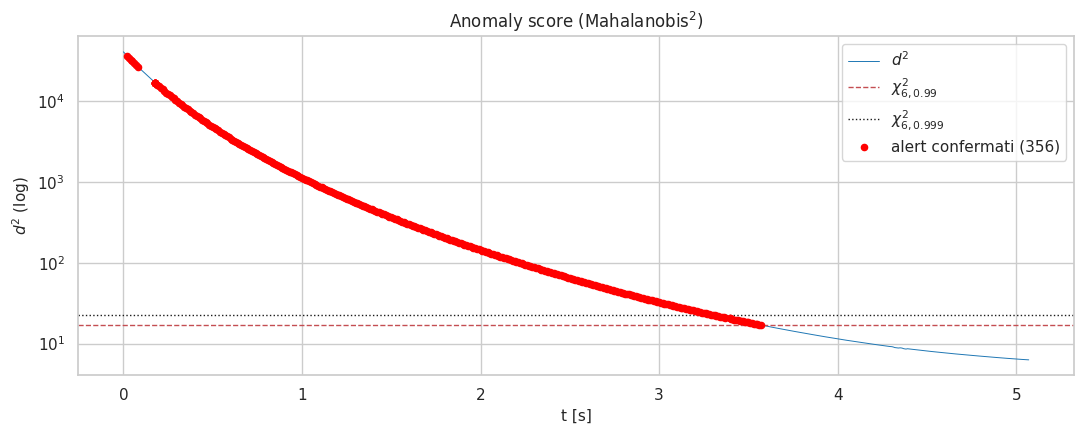

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(df.t_s, df.d2, lw=0.7, color="#1f77b4", label=r"$d^2$")
ax.axhline(16.81, color="r", ls="--", lw=1, label=r"$\chi^2_{6,0.99}$")
ax.axhline(22.46, color="k", ls=":",  lw=1, label=r"$\chi^2_{6,0.999}$")
alerts = df[df.maneuver == 1]
ax.scatter(alerts.t_s, alerts.d2, color="red", s=20, zorder=5,
           label=f"alert confermati ({len(alerts)})")
ax.set_yscale("log")
ax.set_xlabel("t [s]"); ax.set_ylabel(r"$d^2$ (log)")
ax.set_title("Anomaly score (Mahalanobis$^2$)")
ax.legend(loc="upper right"); plt.tight_layout(); plt.show()

## 6. Distribuzione di $d^2$ vs $\chi^2_6$

Se il filtro è **consistente** (la matrice di covarianza $P$ è ben tarata), la distribuzione empirica di $d^2$ deve combaciare con la $\chi^2$ a 6 gradi di libertà.

- istogramma azzurro: dati;
- curva nera: PDF teorica $\chi^2_6$;
- KS-test: p-value > 0.05 ⇒ non rifiutiamo l'ipotesi di consistenza.

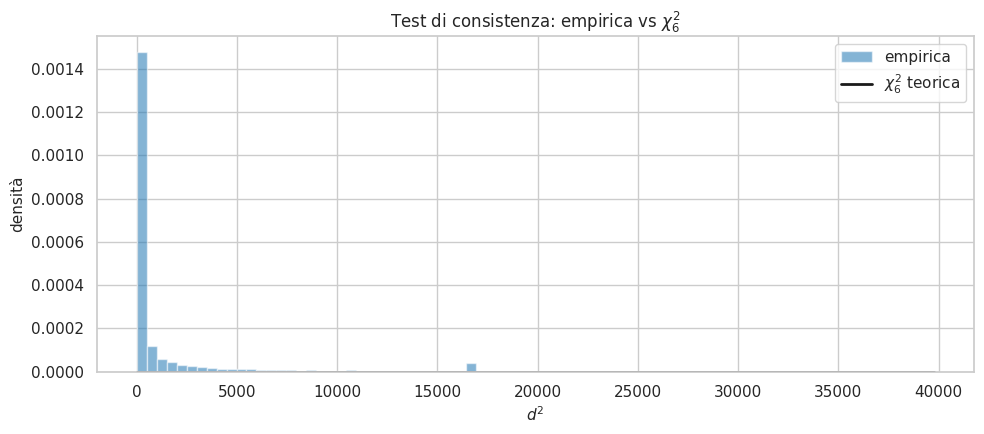

Kolmogorov-Smirnov: D = 0.7172   p-value = 4.72e-265
  (p > 0.05 ⇒ filtro consistente; p << 0.05 ⇒ Q o R sono mal tarate)


In [6]:
data = df.d2.clip(upper=df.d2.quantile(0.999))   # togli code estreme per leggibilità
x = np.linspace(0, data.max(), 400)
pdf = stats.chi2.pdf(x, df=6)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(data, bins=80, density=True, alpha=0.55, color="#1f77b4", label="empirica")
ax.plot(x, pdf, color="k", lw=2, label=r"$\chi^2_6$ teorica")
ax.set_xlabel(r"$d^2$"); ax.set_ylabel("densità")
ax.set_title("Test di consistenza: empirica vs $\\chi^2_6$")
ax.legend(); plt.tight_layout(); plt.show()

ks = stats.kstest(data, "chi2", args=(6,))
print(f"Kolmogorov-Smirnov: D = {ks.statistic:.4f}   p-value = {ks.pvalue:.4g}")
print("  (p > 0.05 ⇒ filtro consistente; p << 0.05 ⇒ Q o R sono mal tarate)")

## 7. Statistica dei residui

Pair-plot dei tre residui posizionali — devono apparire **gaussiani, zero-mean, scorrelati**.

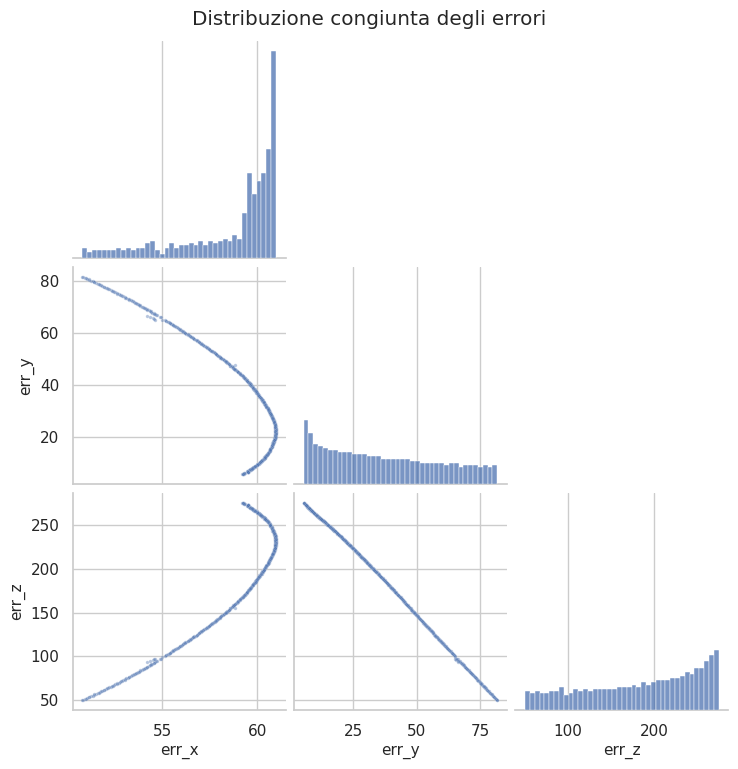

err_x: mean=+58548.89 mm   std=2746.88 mm   skew=-1.26   kurt=+0.42
err_y: mean=+37143.74 mm   std=22181.15 mm   skew=+0.33   kurt=-1.09
err_z: mean=+184608.11 mm   std=66354.63 mm   skew=-0.40   kurt=-1.07


In [7]:
g = sns.pairplot(df[["err_x", "err_y", "err_z"]].sample(min(2000, len(df))),
                 corner=True, plot_kws=dict(s=6, alpha=0.4),
                 diag_kws=dict(bins=40))
g.fig.suptitle("Distribuzione congiunta degli errori", y=1.02)
plt.show()

for c in ["err_x", "err_y", "err_z"]:
    s = df[c]
    print(f"{c}: mean={s.mean()*1000:+6.2f} mm   std={s.std()*1000:5.2f} mm   "
          f"skew={s.skew():+.2f}   kurt={s.kurt():+.2f}")

## 8. Diagnostica timing

Verifica che la pipeline regga **100 Hz** (1 pacchetto ogni 10 ms).

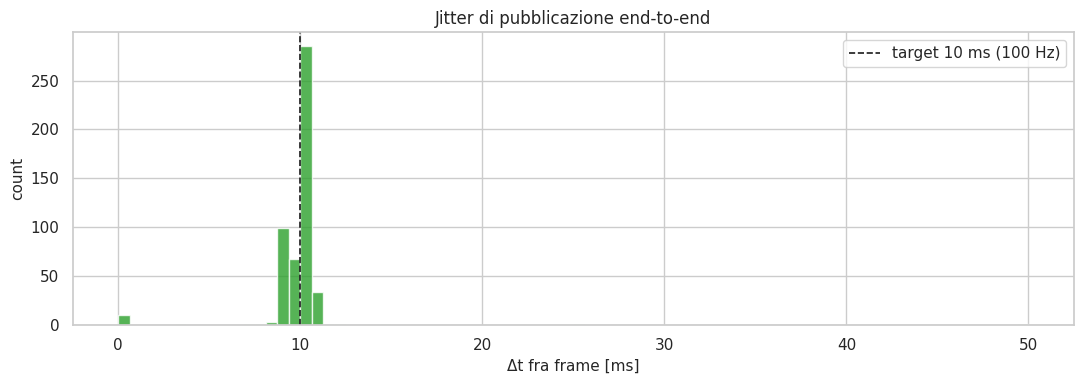

Δt  mean : 10.00 ms
Δt  p50  : 10.18 ms
Δt  p99  : 11.11 ms
Δt  max  : 98.83 ms


In [8]:
dt_ms = df.t_s.diff().dropna() * 1000
fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(dt_ms.clip(upper=50), bins=80, color="#2ca02c", alpha=0.8)
ax.axvline(10, color="k", ls="--", label="target 10 ms (100 Hz)")
ax.set_xlabel("Δt fra frame [ms]"); ax.set_ylabel("count")
ax.set_title("Jitter di pubblicazione end-to-end")
ax.legend(); plt.tight_layout(); plt.show()

print(f"Δt  mean : {dt_ms.mean():.2f} ms")
print(f"Δt  p50  : {dt_ms.quantile(0.50):.2f} ms")
print(f"Δt  p99  : {dt_ms.quantile(0.99):.2f} ms")
print(f"Δt  max  : {dt_ms.max():.2f} ms")

## 9. (Opzionale) Test di manovra

Per verificare il rivelatore: modifica `a_cmd` in `simulation_engine/main.jl` con uno step temporale (es. accelerazione laterale a $t = 20\,\text{s}$), rilancia `./run_demo.sh 60`, e guarda se i marker rossi della cella 5 si concentrano nell'intorno dell'evento.

Snippet da inserire in `drift!`:

```julia
ax = t < 20.0 ? 0.0 : 20.0
du[4] = ax + u[7]
```

## 10. 🎥 Replay animato (GIF)

Genera una GIF di replay del run con la traiettoria che si "disegna" da sola e un pannello dell'errore che scrolla.
Output salvato in `replay.gif`. È pensata per girare anche su GPU integrata (è solo matplotlib + Pillow).


Rendering 300 frames a 25 FPS -> replay.gif ...


Salvato replay.gif


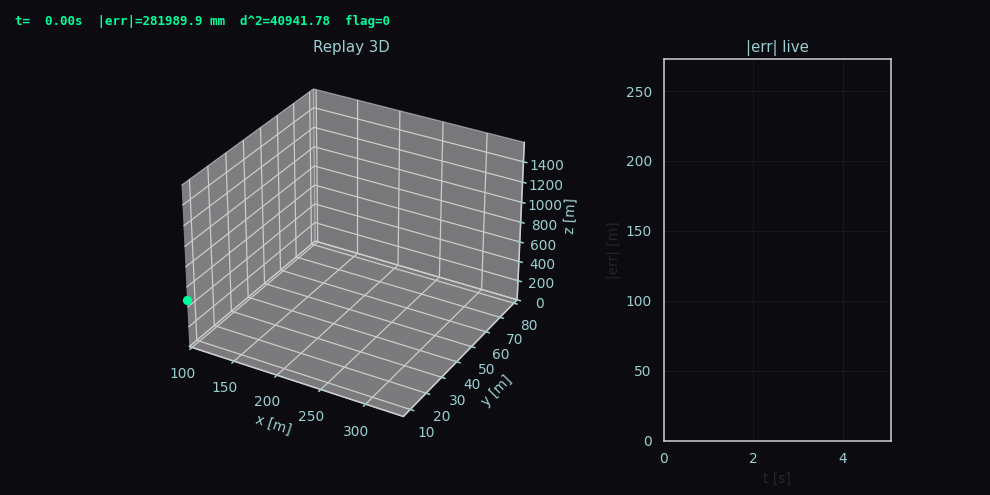

In [9]:
from matplotlib.animation import FuncAnimation, PillowWriter
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# --- parametri replay --------------------------------------------------------
REPLAY_FPS      = 25
REPLAY_DURATION = 12.0     # secondi di GIF (compressione temporale del run)
REPLAY_TRAIL    = 200      # numero di sample mostrati nella scia mobile
OUT_PATH        = "replay.gif"

# Sottocampiona uniformemente per ottenere il numero giusto di frame
n_frames = int(REPLAY_FPS * REPLAY_DURATION)
idx      = np.linspace(0, len(df) - 1, n_frames).astype(int)

fig = plt.figure(figsize=(11, 5.5), facecolor="#0b0b10")
gs  = fig.add_gridspec(1, 2, width_ratios=[2, 1], wspace=0.25)
ax3 = fig.add_subplot(gs[0, 0], projection="3d")
axe = fig.add_subplot(gs[0, 1])
for ax in (ax3, axe):
    ax.set_facecolor("#0b0b10")
ax3.set_title("Replay 3D", color="#9bd1d1")
axe.set_title("|err| live", color="#9bd1d1")
axe.set_xlabel("t [s]"); axe.set_ylabel("|err| [m]")
axe.tick_params(colors="#9bd1d1"); axe.grid(alpha=0.3, color="#1f3a3a")

# limiti fissi calcolati una volta
ax3.set_xlim(df.px.min(), df.px.max())
ax3.set_ylim(df.py.min(), df.py.max())
ax3.set_zlim(0, df.pz.max() * 1.05)
ax3.set_xlabel("x [m]"); ax3.set_ylabel("y [m]"); ax3.set_zlabel("z [m]")
for axis in (ax3.xaxis, ax3.yaxis, ax3.zaxis):
    axis.label.set_color("#9bd1d1")
    axis.set_tick_params(colors="#9bd1d1")

l_truth, = ax3.plot([], [], [], color="#00ff9a", lw=1.4)
l_est,   = ax3.plot([], [], [], color="#ffb000", lw=1.0, alpha=0.95)
h_truth  = ax3.scatter([df.px.iloc[0]], [df.py.iloc[0]], [df.pz.iloc[0]],
                       c="#00ff9a", s=40)
h_est    = ax3.scatter([df.ex.iloc[0]], [df.ey.iloc[0]], [df.ez.iloc[0]],
                       c="#ffb000", s=20)
l_err,   = axe.plot([], [], color="#ffb000", lw=1.0)
axe.set_xlim(0, df.t_s.iloc[-1])
axe.set_ylim(0, max(0.2, df.err_norm.iloc[REPLAY_TRAIL:].quantile(0.99) * 1.2))

hud = fig.text(0.015, 0.95, "", color="#00ff9a", fontsize=10,
               family="monospace", fontweight="bold")

def frame(k):
    i = idx[k]
    j = max(0, i - REPLAY_TRAIL)
    sub = df.iloc[j:i+1]
    l_truth.set_data_3d(sub.px.values, sub.py.values, sub.pz.values)
    l_est.set_data_3d(sub.ex.values,  sub.ey.values,  sub.ez.values)
    h_truth._offsets3d = ([sub.px.iloc[-1]], [sub.py.iloc[-1]], [sub.pz.iloc[-1]])
    h_est._offsets3d   = ([sub.ex.iloc[-1]], [sub.ey.iloc[-1]], [sub.ez.iloc[-1]])
    l_err.set_data(df.t_s.iloc[:i+1].values, df.err_norm.iloc[:i+1].values)
    hud.set_text(f"t={df.t_s.iloc[i]:6.2f}s  |err|={df.err_norm.iloc[i]*1000:7.1f} mm  "
                 f"d^2={df.d2.iloc[i]:8.2f}  flag={int(df.maneuver.iloc[i])}")
    return l_truth, l_est, l_err

print(f"Rendering {n_frames} frames a {REPLAY_FPS} FPS -> {OUT_PATH} ...")
anim = FuncAnimation(fig, frame, frames=n_frames, interval=1000/REPLAY_FPS, blit=False)
anim.save(OUT_PATH, writer=PillowWriter(fps=REPLAY_FPS), dpi=90)
plt.close(fig)
print(f"Salvato {OUT_PATH}")

from IPython.display import Image
Image(OUT_PATH)


## 11. 🌐 Scena 3D interattiva (Plotly)

Plot 3D che puoi **ruotare, zoomare e ispezionare** col mouse, direttamente nel notebook.
Renderizza in WebGL nel browser → la GPU integrata Iris Xe se la cava benissimo.
Il colore della traiettoria stimata è proporzionale all'incertezza posizionale $\sqrt{\mathrm{tr}(P_{xyz})}$.


In [10]:
import plotly.graph_objects as go

# sotto-campiono se troppi punti (UI fluida anche con 30k+ sample)
MAX_PTS = 4000
step    = max(1, len(df) // MAX_PTS)
d       = df.iloc[::step].reset_index(drop=True)

# colore = d^2 in scala log (clippato per leggibilità)
color_d2 = np.log10(np.clip(d.d2.values, 1e-2, 1e4))

fig = go.Figure()

# truth (verde)
fig.add_trace(go.Scatter3d(
    x=d.px, y=d.py, z=d.pz, mode="lines",
    line=dict(color="#00ff9a", width=4),
    name="truth (sim)",
    hovertemplate="t=%{customdata:.2f}s<br>x=%{x:.2f} y=%{y:.2f} z=%{z:.2f}<extra>truth</extra>",
    customdata=d.t_s,
))

# estimate (colorato in base a d^2)
fig.add_trace(go.Scatter3d(
    x=d.ex, y=d.ey, z=d.ez, mode="lines+markers",
    marker=dict(size=2, color=color_d2, colorscale="Plasma",
                colorbar=dict(title="log10 d²", thickness=14)),
    line=dict(color="#ffb000", width=2),
    name="EKF estimate",
    hovertemplate=("t=%{customdata[0]:.2f}s<br>"
                   "|err|=%{customdata[1]:.3f} m<br>"
                   "d²=%{customdata[2]:.2f}"
                   "<extra>EKF</extra>"),
    customdata=np.stack([d.t_s, d.err_norm, d.d2], axis=-1),
))

# alert (puntini rossi)
al = d[d.maneuver == 1]
if len(al):
    fig.add_trace(go.Scatter3d(
        x=al.ex, y=al.ey, z=al.ez, mode="markers",
        marker=dict(size=4, color="#ff2e63", symbol="diamond"),
        name="alert (maneuver)",
    ))

fig.update_layout(
    title="AEGIS-LINK — scena 3D interattiva",
    template="plotly_dark",
    paper_bgcolor="#0b0b10",
    scene=dict(
        xaxis=dict(title="x [m]", backgroundcolor="#0b0b10"),
        yaxis=dict(title="y [m]", backgroundcolor="#0b0b10"),
        zaxis=dict(title="z [m]", backgroundcolor="#0b0b10"),
        aspectmode="data",
    ),
    legend=dict(orientation="h", y=1.02, x=0),
    margin=dict(l=0, r=0, t=40, b=0),
    height=620,
)
fig.show()


## 12. 🎯 Fire-control / engagement performance

Questa sezione analizza la nuova catena **track → lock → engage → knock-down**
introdotta dal modulo `engagement_engine` (PN interceptor, vedi README §
"Fire-control loop").

Due fonti di dati:

1. **`engagement.csv`** — telemetria per-frame di un singolo engagement,
   scritta da `engagement_engine/main.py` durante `./run_demo.sh`.
2. **`mc_results.csv`** — riassunto per-run di un batch Monte-Carlo,
   scritto da `./mc_demo.sh N`.

Se il file Monte-Carlo non esiste, la sezione mostra solo la singola run.


In [ ]:
import os, pandas as pd, numpy as np, matplotlib.pyplot as plt

# --- Singolo engagement: traiettoria interceptor + closing range -----------
eng_path = "engagement.csv"
if os.path.exists(eng_path) and os.path.getsize(eng_path) > 0:
    eng = pd.read_csv(eng_path)
    print(f"engagement.csv : {len(eng)} righe   stati: "
          f"{sorted(eng['state'].dropna().unique())}")
    if "range" in eng.columns and (eng["state"] == "ENGAGED").any():
        engaged = eng[eng["state"] == "ENGAGED"].copy()
        engaged["t_rel_s"] = (engaged["ts_ns"] - engaged["ts_ns"].iloc[0]) * 1e-9
        fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
        ax[0].plot(engaged["t_rel_s"], engaged["range"],     color="tab:cyan")
        ax[0].plot(engaged["t_rel_s"], engaged["pred_miss"], color="tab:pink",
                   ls="--", label="predicted CPA")
        ax[0].axhline(5.0, color="tab:red", ls=":", lw=0.8, label="lethal radius")
        ax[0].set(xlabel="t since launch [s]", ylabel="range [m]",
                  title="LOS range and predicted miss")
        ax[0].legend(); ax[0].grid(alpha=0.3)
        ax[1].plot(engaged["t_rel_s"], engaged["closing"], color="tab:orange")
        ax[1].set(xlabel="t since launch [s]", ylabel="closing speed [m/s]",
                  title="Closing speed")
        ax[1].grid(alpha=0.3)
        plt.tight_layout(); plt.show()
        cpa = float(engaged["range"].min())
        print(f"CPA (single run): {cpa:.2f} m")
else:
    print("engagement.csv non trovato — esegui prima ./run_demo.sh")

# --- Monte-Carlo: Pk + miss-distance + time-to-kill ------------------------
mc_path = "mc_results.csv"
if os.path.exists(mc_path) and os.path.getsize(mc_path) > 0:
    mc = pd.read_csv(mc_path)
    n   = len(mc)
    nk  = int((mc["outcome"] == "KILL").sum())
    pk  = nk / max(n, 1)
    print(f"\nMonte-Carlo: {n} engagement, {nk} KILL, Pk = {pk:.3f}")
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
    kills = mc[mc["outcome"] == "KILL"]
    if len(kills):
        ax[0].hist(kills["cpa_m"].astype(float), bins=20, color="#00d9ff",
                   edgecolor="k", alpha=0.85)
        ax[0].axvline(5.0, color="tab:red", ls=":", label="lethal radius")
        ax[0].set(xlabel="CPA [m]", ylabel="count",
                  title=f"Miss-distance (KILL only, N={len(kills)})")
        ax[0].legend(); ax[0].grid(alpha=0.3)
        ax[1].hist(kills["flight_time_s"].astype(float), bins=20,
                   color="#ffb000", edgecolor="k", alpha=0.85)
        ax[1].set(xlabel="time to kill [s]", ylabel="count",
                  title="Engagement duration (KILL)")
        ax[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("\nmc_results.csv non trovato — esegui ./mc_demo.sh N per il batch.")


## 13. 📡 Passive IRST sensor performance

This section analyses the **IRST (Infrared Search and Track)** sensor added
in PR #4.  The IR sensor runs as a separate process (`ir_sensor/main.py`)
and writes one row per emitted 128-byte packet to **`ir_sensor.csv`**
when launched with `--csv ir_sensor.csv` (the default in `run_demo.sh`).

**Column map** (`ir_sensor.csv`):

| column | meaning |
|--------|---------|
| `ts_ns` | producer-side TAI timestamp [ns] |
| `is_false_alarm` | 1 for injected clutter, 0 for true detection |
| `px/py/pz` | estimated ENU position [m] |
| `vx/vy/vz` | finite-difference velocity estimate [m/s] |
| `var_x/var_y/var_z` | positional variances [m²] (cross-range small, along-range large) |
| `var_vel` | velocity variance [m²/s²] |
| `snr` | linear SNR at focal plane (diagnostic) |
| `tau` | one-way atmospheric transmission (diagnostic) |

If `ir_sensor.csv` is absent (older run or IR process not started) the
section prints a note and exits gracefully without raising an error.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

IR_PATH = "ir_sensor.csv"

if not (os.path.exists(IR_PATH) and os.path.getsize(IR_PATH) > 0):
    print("ir_sensor.csv non trovato — esegui ./run_demo.sh (con IR process) per generarlo.")
else:
    ir = pd.read_csv(IR_PATH)
    ir["t_s"] = (ir["ts_ns"] - ir["ts_ns"].iloc[0]) * 1e-9

    true_det = ir[ir["is_false_alarm"] == 0].copy()
    fa_det   = ir[ir["is_false_alarm"] == 1].copy()

    print(f"ir_sensor.csv: {len(ir)} rows  "
          f"({len(true_det)} true detections, {len(fa_det)} false alarms)")

    if len(true_det) == 0:
        print("No true detections found — try a longer run.")
    else:
        # -----------------------------------------------------------------
        # 1. SNR vs slant range to sensor
        # -----------------------------------------------------------------
        true_det["slant_range_m"] = np.sqrt(
            true_det["px"]**2 + true_det["py"]**2 + true_det["pz"]**2)

        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        fig.suptitle("IRST sensor performance", fontsize=13, weight="bold")

        ax = axes[0, 0]
        ax.scatter(true_det["slant_range_m"] / 1e3, true_det["snr"],
                   c="#ff5a36", s=6, alpha=0.6, label="true det.")
        ax.set(xlabel="slant range [km]", ylabel="SNR",
               title="SNR vs slant range", yscale="log")
        ax.axhline(4.0, color="gray", ls="--", lw=0.8, label="detect threshold")
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

        # -----------------------------------------------------------------
        # 2. Atmospheric transmission vs time
        # -----------------------------------------------------------------
        ax = axes[0, 1]
        ax.plot(true_det["t_s"], true_det["tau"], color="#ff5a36", lw=1.0)
        ax.set(xlabel="t [s]", ylabel="τ (atmospheric transmission)",
               title="MWIR atmospheric transmission", ylim=(0, 1.05))
        ax.grid(alpha=0.3)

        # -----------------------------------------------------------------
        # 3. Position error vs truth (join to run.csv on nearest ts_ns)
        # -----------------------------------------------------------------
        run_path = "run.csv"
        ax = axes[1, 0]
        if os.path.exists(run_path) and os.path.getsize(run_path) > 0:
            try:
                run = pd.read_csv(run_path)
                # run.csv uses columns: ts_ns, px_truth, py_truth, pz_truth
                # (column names from ai_orchestrator output)
                truth_cols = [c for c in run.columns if "truth" in c.lower() or c.startswith("px") or c.startswith("py") or c.startswith("pz")]
                # Use ts_ns merge — merge_asof requires sorted keys
                td2 = true_det[["ts_ns", "px", "py", "pz", "t_s"]].sort_values("ts_ns").reset_index(drop=True)
                tr2 = run.sort_values("ts_ns").reset_index(drop=True)
                # Identify truth position columns robustly
                px_col = next((c for c in tr2.columns if "px" in c and "truth" in c.lower()), None)
                py_col = next((c for c in tr2.columns if "py" in c and "truth" in c.lower()), None)
                pz_col = next((c for c in tr2.columns if "pz" in c and "truth" in c.lower()), None)
                if px_col and py_col and pz_col:
                    merged = pd.merge_asof(td2, tr2[["ts_ns", px_col, py_col, pz_col]],
                                           on="ts_ns", tolerance=20_000_000)
                    merged = merged.dropna()
                    if len(merged):
                        pos_err = np.sqrt((merged["px"] - merged[px_col])**2 +
                                          (merged["py"] - merged[py_col])**2 +
                                          (merged["pz"] - merged[pz_col])**2)
                        ax.plot(merged["t_s"], pos_err, color="#ff5a36", lw=1.0)
                        ax.set(xlabel="t [s]", ylabel="position error [m]",
                               title="IR position error vs truth", yscale="log")
                        ax.grid(alpha=0.3)
                    else:
                        ax.text(0.5, 0.5, "No matching timestamps",
                                ha="center", transform=ax.transAxes)
                else:
                    ax.text(0.5, 0.5, "run.csv columns not recognised",
                            ha="center", transform=ax.transAxes)
            except Exception as exc:
                ax.text(0.5, 0.5, f"run.csv error: {exc}",
                        ha="center", transform=ax.transAxes)
        else:
            ax.text(0.5, 0.5, "run.csv not found",
                    ha="center", transform=ax.transAxes)
            ax.set_title("IR position error vs truth (unavailable)")

        # -----------------------------------------------------------------
        # 4. Along-range vs cross-range variance (bearing-only structure)
        # -----------------------------------------------------------------
        ax = axes[1, 1]
        cross_range_var = np.minimum(true_det["var_x"], true_det["var_y"])
        along_range_var = np.maximum(true_det["var_x"], true_det["var_y"])
        ax.scatter(true_det["t_s"], np.sqrt(cross_range_var),
                   c="#00ff9a", s=5, alpha=0.6, label="σ_cross [m]")
        ax.scatter(true_det["t_s"], np.sqrt(along_range_var),
                   c="#ff5a36", s=5, alpha=0.6, label="σ_along [m]")
        ax.set(xlabel="t [s]", ylabel="1-σ position uncertainty [m]",
               title="Bearing-only covariance structure", yscale="log")
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

        if len(fa_det):
            print(f"\nFalse-alarm positions (first 5):")
            print(fa_det[["ts_ns", "px", "py", "pz"]].head())
